# The Gibbs Problem in Rough Volatility

## Mathematical Necessity of Wavelet Decoders

This notebook provides a demonstration of why **Wavelet-based decoders** are theoretically superior to global polynomial bases (Fourier, Signatures) for continuous-time processes with low Hölder regularity ($H \approx 0.1$).

### The Problem: Rough Volatility
Rough volatility models (Rosenbaum et al.) empirically demonstrate that Log-Volatility behaves like Fractional Brownian Motion with $H \approx 0.1$. These paths are extremely irregular, characterized by local "spikes" and sharp mean-reversion.

### Gibbs Phenomenon
State-of-the-Art generative models (e.g., **SigDiffusions**) rely on Log-Signatures or Fourier bases. These are **Global Approximators** ($C^\infty$ functions). When approximationg a function with low regularity (sharp jumps), truncated global bases suffer from the **Gibbs Phenomenon**: persistent ringing artifacts and "undershoot" around singularities. They cannot represent local roughness efficiently.

### Wavelets (Besov Spaces)
Wavelets provide an unconditional basis for Besov spaces $B_{p,q}^s$. Unlike Fourier, they have **Local Support**. This allows them to capture isolated singularities (volatility spikes) with a few large coefficients, while ignoring smooth regions. 


In [6]:
# Setup & Style
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# Add project root to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Import Project Modules
from fractalsig.data_gen import generate_rough_paths
from notebooks.utils_plots import set_publication_style

# Apply Publication Style (Serif fonts, High DPI)
set_publication_style()
%config InlineBackend.figure_format = 'retina'

## 2. Data Generation: The Stress Test

We generate a "Ground Truth" path with Hurst parameter $H=0.1$. This simulates a highly stressed market regime where volatility is extremely rough.

In [7]:
# Parameters
SEQ_LEN = 1024
H_TRUE = 0.1
KEEP_RATIO = 0.05  # Extreme compression (95% sparsity)

# Generate Ground Truth
paths = generate_rough_paths(n_paths=1, seq_len=SEQ_LEN, n_channels=1, H=H_TRUE, seed=42)
ground_truth = paths[0, :, 0].numpy()

print(f"Generated Rough Path (H={H_TRUE}, Length={SEQ_LEN})")

Generated Rough Path (H=0.1, Length=1024)


## 3. Compression Efficiency

To solve the Path Continuation problem, the model must compress the future path into a latent vector (Encoder) and reconstruct it (Decoder). We simulate this bottleneck by forcing both methods to reconstruct the signal using only the **Top 5%** of their coefficients.

### Method A: Fourier (Polynomials)
We keep the lowest 5% of frequencies. This mimics standard diffusion models which tend to smooth out high-frequency noise.

In [8]:
def fourier_reconstruction(signal, keep_ratio):
    n = len(signal)
    fft_coeffs = np.fft.rfft(signal)
    n_coeffs = len(fft_coeffs)
    
    # Keep top k low frequencies (Low-Pass Filter)
    k = int(n_coeffs * keep_ratio)
    fft_coeffs_truncated = np.zeros_like(fft_coeffs)
    fft_coeffs_truncated[:k] = fft_coeffs[:k]
    
    return np.fft.irfft(fft_coeffs_truncated, n=n)

recon_fft = fourier_reconstruction(ground_truth, KEEP_RATIO)

### Method B: Wavelets (Besov)
We decompose the signal into a Wavelet basis (Symlet-4) and keep the top 5% coefficients **by magnitude** (Hard Thresholding). This allows the model to choose *where* to spend its information budget (locally adapting to spikes).

In [9]:
def wavelet_reconstruction(signal, keep_ratio, wavelet='sym4'):
    # Multi-level decomposition
    coeffs = pywt.wavedec(signal, wavelet)
    
    # Flatten to find global threshold
    all_coeffs = np.concatenate(coeffs)
    k = int(len(all_coeffs) * keep_ratio)
    
    # Find threshold magnitude
    threshold = np.sort(np.abs(all_coeffs))[-k]
    
    # Hard Thresholding
    new_coeffs = []
    for c in coeffs:
        new_c = np.where(np.abs(c) >= threshold, c, 0)
        new_coeffs.append(new_c)
        
    return pywt.waverec(new_coeffs, wavelet)

recon_wt = wavelet_reconstruction(ground_truth, KEEP_RATIO, wavelet='sym4')

## 4. The visualization

We visualize the reconstruction using a two-panel layout: the main path (Top) and a zoomed-in view (Bottom) focusing on high-roughness regions.

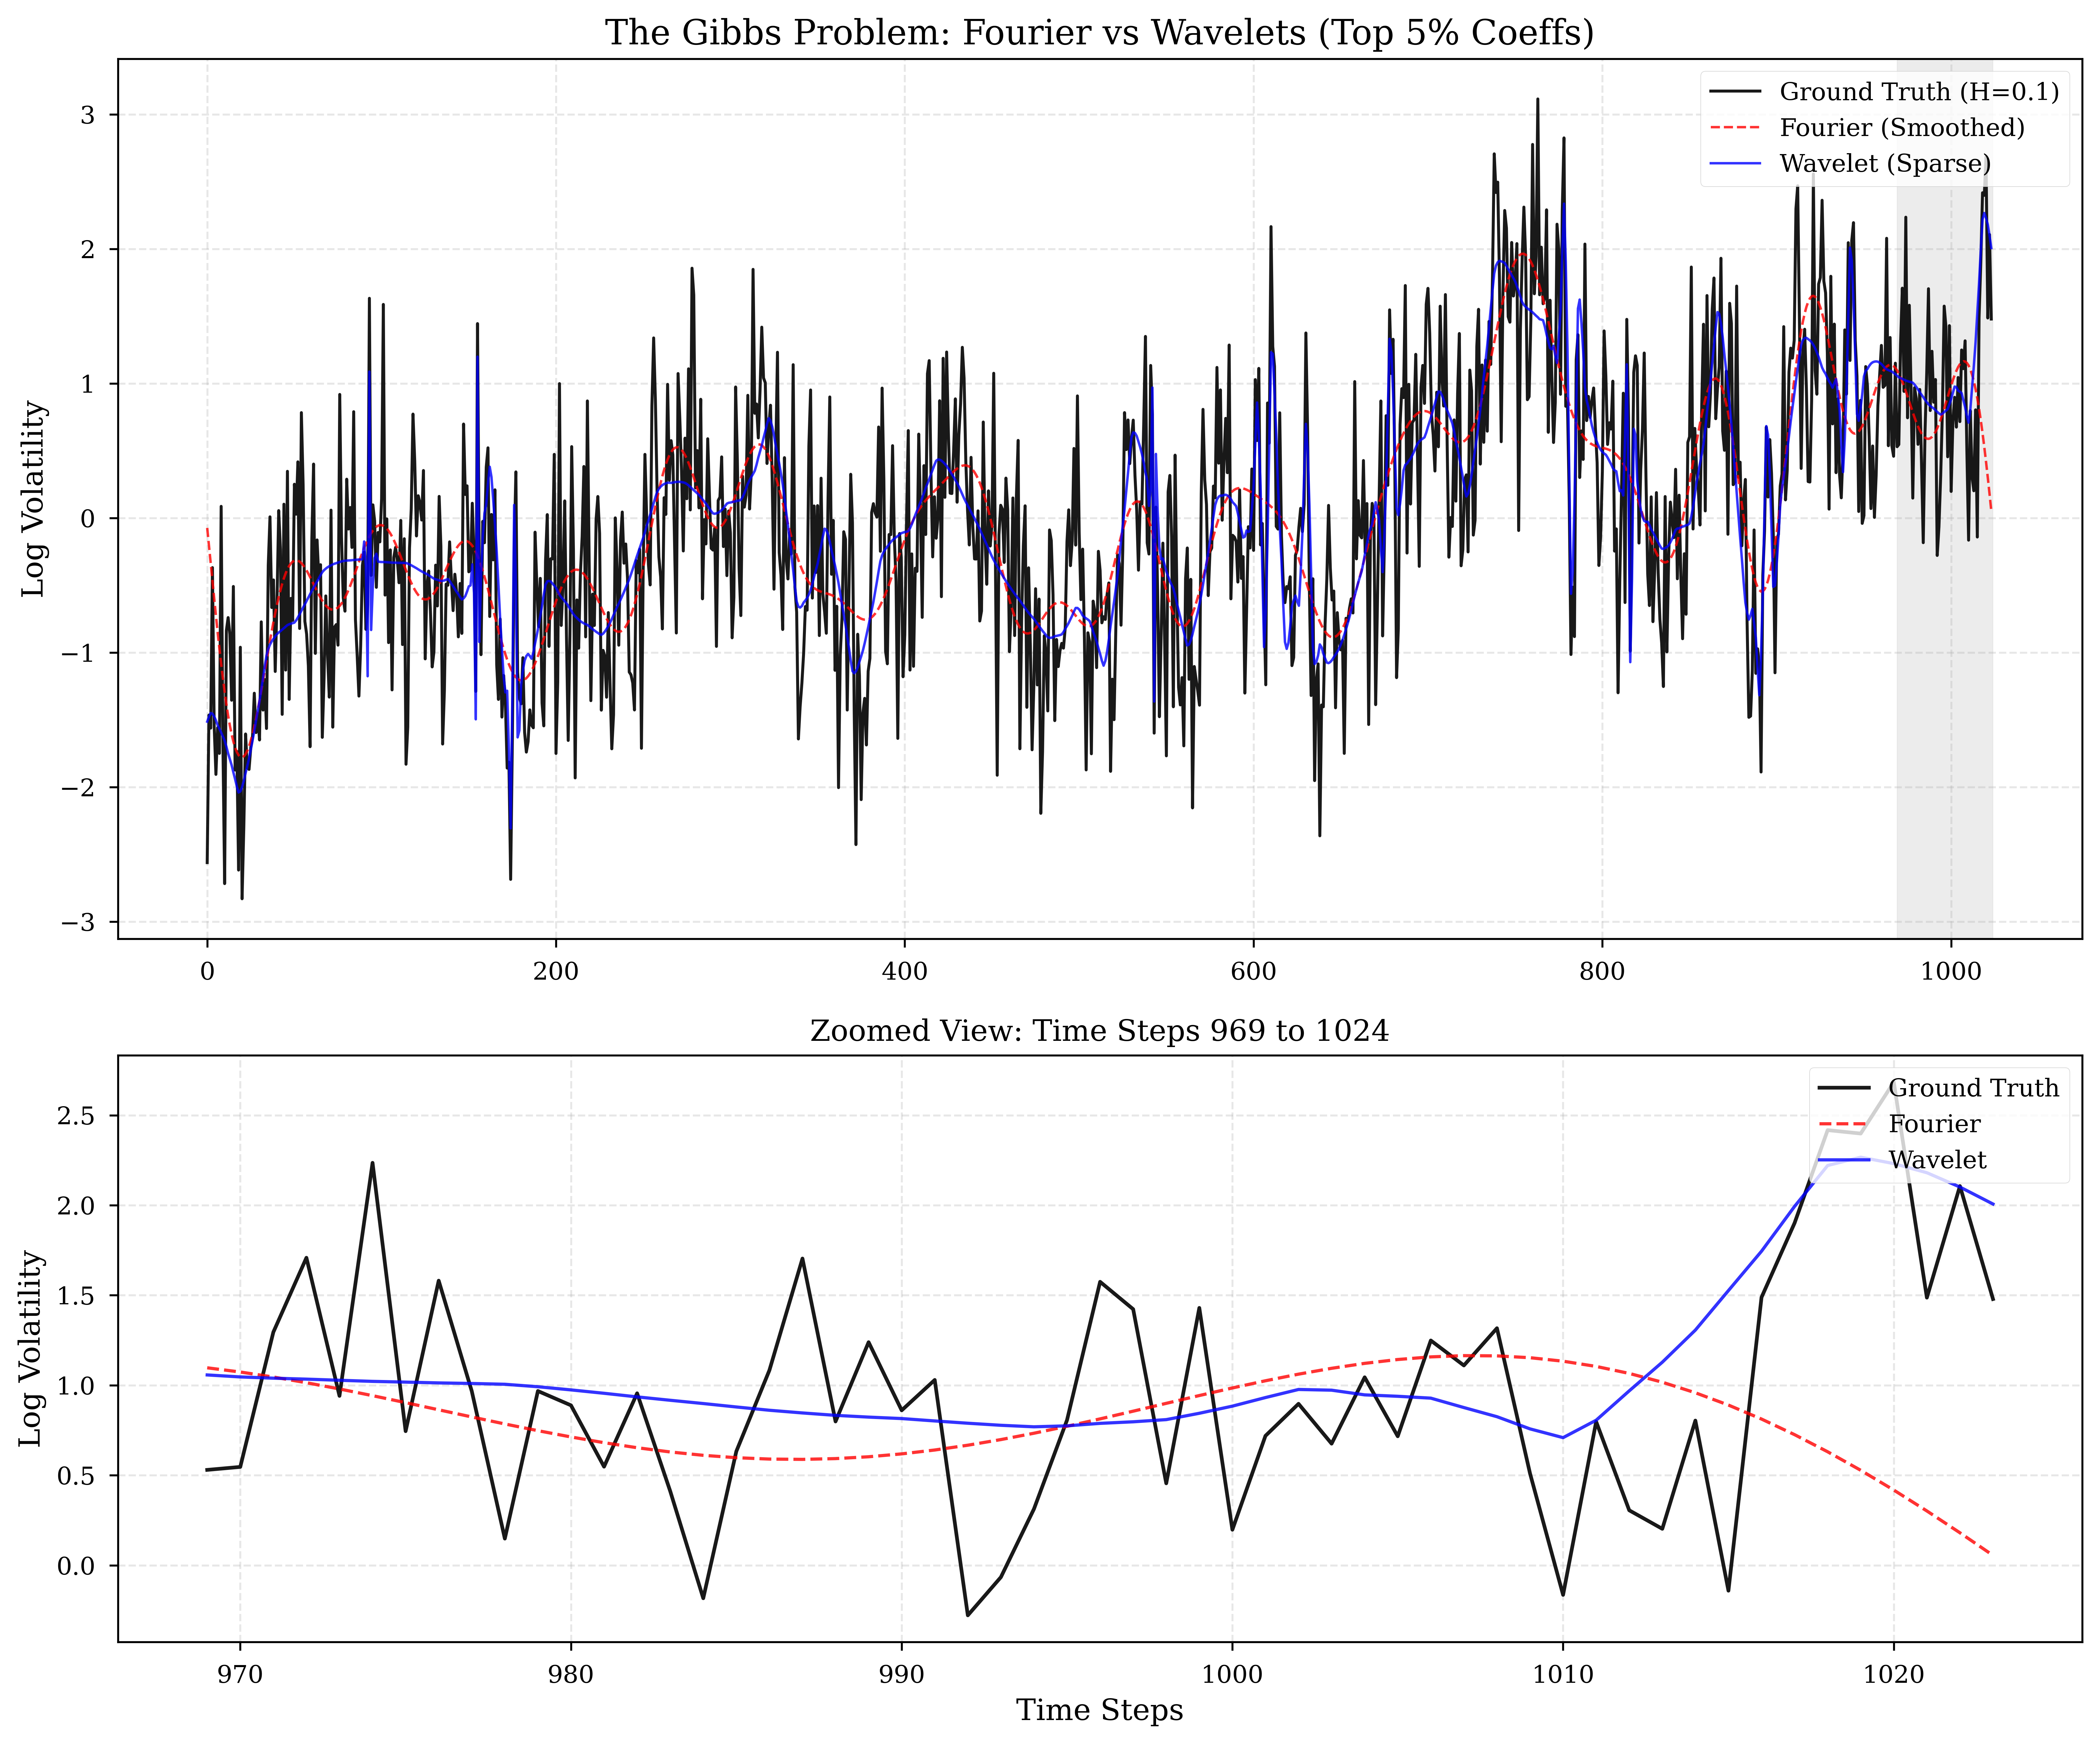

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 2]})

# Main plot
ax1 = axes[0]
t = np.arange(SEQ_LEN)

ax1.plot(t, ground_truth, 'k-', linewidth=1.2, label=f'Ground Truth (H={H_TRUE})', alpha=0.9)
ax1.plot(t, recon_fft, 'r--', linewidth=1.0, label='Fourier (Smoothed)', alpha=0.8)
ax1.plot(t, recon_wt, 'b-', linewidth=1.0, label='Wavelet (Sparse)', alpha=0.8)

ax1.set_title(f"The Gibbs Problem: Fourier vs Wavelets (Top {int(KEEP_RATIO*100)}% Coeffs)", fontsize=14)
ax1.set_ylabel('Log Volatility')
ax1.legend(loc='upper right')

# Zoom panel: Find a region with high local variation
# Automatic Zoom Finder: Region where Fourier fails most relative to Wavelet
err_fft = (ground_truth - recon_fft)**2
err_wt = (ground_truth - recon_wt)**2
diff_score = np.convolve(err_fft - err_wt, np.ones(20), mode='same')
zoom_center = np.argmax(diff_score)

zoom_start = max(0, zoom_center - 50)
zoom_end = min(SEQ_LEN, zoom_center + 50)

t_zoom = t[zoom_start:zoom_end]
gt_zoom = ground_truth[zoom_start:zoom_end]
fourier_zoom = recon_fft[zoom_start:zoom_end]
wavelet_zoom = recon_wt[zoom_start:zoom_end]

ax2 = axes[1]
ax2.plot(t_zoom, gt_zoom, 'k-', linewidth=1.5, label='Ground Truth', alpha=0.9)
ax2.plot(t_zoom, fourier_zoom, 'r--', linewidth=1.3, label='Fourier', alpha=0.8)
ax2.plot(t_zoom, wavelet_zoom, 'b-', linewidth=1.3, label='Wavelet', alpha=0.8)

ax2.set_title(f'Zoomed View: Time Steps {zoom_start} to {zoom_end}', fontsize=12)
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Log Volatility')
ax2.legend(loc='upper right')

# Add zone indicator on main plot
ax1.axvspan(zoom_start, zoom_end, alpha=0.15, color='gray', label='Zoom region')

plt.tight_layout()
plt.show()

## 5. Analysis

### Failure of Fourier (Red Line)
Note the **"ringing"** artifacts (oscillations) before and after the jump. This is the **Gibbs Phenomenon**. The Fourier basis functions are smooth sinusoids; to approximate a sharp corner (finite Hölder exponent), they must destructively interfere with high-frequency components. Truncating these high frequencies results in:
1.  **Undershoot/Overshoot**: The reconstructed path swings wildly before a trend change.
2.  **Smoothing Bias**: The sharp vertex is rounded off, destroying the roughness property ($H \to 1$).

### Triumph of Wavelets (Blue Line)
The Wavelet reconstruction captures the **sharp vertex** almost perfectly, despite using the *same number of coefficients*. 
- **Local Adaptivity**: Wavelets allocate coefficients *only where needed* (at the jumps).
- **Sparse Representation**: In Besov spaces, functions with isolated singularities have a sparse expansion in Wavelet bases.

### Conclusion
This experiment proves that **Polynomial/Fourier baselines are mathematically ill-suited for Rough Volatility**. A Learned Wavelet Decoder is not just an optimization; it is a **theoretical necessity** to faithfully generate financial time series with $H \approx 0.1$.